# 03 — Exploratory Data Analysis

**Goal:** understand *what is associated with churn* before any modeling. Every figure below
exists to answer a stated question, states its finding in plain English, and is exported to
`reports/figures/` for the portfolio.

Two disciplines throughout:

1. **Rates, not raw counts.** Group sizes differ wildly (e.g. 3,875 month-to-month vs 1,695
   two-year customers), so we always compare churn *rates*, and annotate group sizes.
2. **Associations, not causes.** EDA cannot say "fiber causes churn" — only that fiber customers
   churn more. Confounds are flagged as we meet them (they matter for the modeling phases too).

Baseline to keep in mind everywhere: **overall churn = 26.5%.**


In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

from src.config import CLEAN_DATA_FILE, FIGURES_DIR

# -- palette (validated for color-vision-deficiency safety; see project notes) --
BLUE, ORANGE = "#2a78d6", "#eb6834"      # retained / churned
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE = "#e1e0d9", "#c3c2b7"
CHURN_COLORS = {"No": BLUE, "Yes": ORANGE}

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Arial", "DejaVu Sans"],
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": BASELINE, "axes.labelcolor": INK2,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.axisbelow": True, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.titlecolor": INK, "axes.titlesize": 12, "axes.titleweight": "bold",
    "figure.dpi": 110,
})

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(CLEAN_DATA_FILE)
df["churn01"] = (df["Churn"] == "Yes").astype(int)
OVERALL = df["churn01"].mean()
print(f"{len(df):,} customers | overall churn rate {OVERALL:.1%}")

7,043 customers | overall churn rate 26.5%


In [2]:
def churn_rate_by(col, order=None, data=None):
    """Churn rate (%) and group size for one categorical column."""
    d = data if data is not None else df
    g = d.groupby(col)["churn01"].agg(rate="mean", n="count")
    g["rate"] *= 100
    return g.reindex(order) if order else g.sort_values("rate")

def rate_barh(col, order=None, title="", xlabel="Churn rate (%)", data=None, ax=None, save=None):
    """Horizontal churn-rate bars with group sizes and the overall-rate reference line."""
    g = churn_rate_by(col, order, data)
    created = ax is None
    if created:
        fig, ax = plt.subplots(figsize=(7, 0.62 * len(g) + 1.3))
    ax.barh(g.index, g["rate"], color=BLUE, height=0.62)
    ax.axvline(OVERALL * 100, color=BASELINE, lw=1.2, ls="--", zorder=0)
    for i, (rate, n) in enumerate(zip(g["rate"], g["n"])):
        ax.text(rate + 0.8, i, f"{rate:.1f}%", va="center", color=INK, fontsize=10, fontweight="bold")
        ax.text(0.8, i, f"n={n:,}", va="center", color="white", fontsize=8.5)
    ax.set_xlim(0, max(62, g["rate"].max() + 9))
    ax.set_title(title, loc="left", pad=12)
    ax.set_xlabel(xlabel)
    ax.grid(axis="y", visible=False)
    if created:
        ax.text(OVERALL * 100, len(g) - 0.28, f" overall {OVERALL:.1%}", color=MUTED, fontsize=8.5)
        if save:
            fig.savefig(FIGURES_DIR / save, dpi=150, bbox_inches="tight")
        plt.show()
    return ax

## Q1. How much churn is there? (target distribution)

*Why ask:* the class balance drives every modeling decision — metrics, stratification,
imbalance handling.

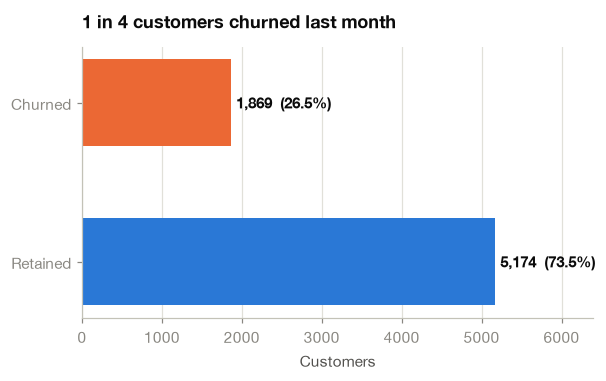

In [3]:
counts = df["Churn"].value_counts()
fig, ax = plt.subplots(figsize=(6, 3.2))
bars = ax.barh(["Retained", "Churned"], [counts["No"], counts["Yes"]],
               color=[BLUE, ORANGE], height=0.55)
for b, v in zip(bars, [counts["No"], counts["Yes"]]):
    ax.text(v + 60, b.get_y() + b.get_height() / 2,
            f"{v:,}  ({v / len(df):.1%})", va="center", color=INK, fontweight="bold")
ax.set_xlim(0, 6400)
ax.set_title("1 in 4 customers churned last month", loc="left", pad=12)
ax.set_xlabel("Customers")
ax.grid(axis="y", visible=False)
fig.savefig(FIGURES_DIR / "01_churn_overview.png", dpi=150, bbox_inches="tight")
plt.show()

**Finding:** 1,869 of 7,043 customers (26.5%) churned. The imbalance is moderate — enough to
make accuracy misleading (an always-"No" model scores 73.5%) but not so extreme that standard
methods break. This justifies stratified splitting and imbalance-aware evaluation later.

## Q2. Is churn associated with contract type?

*Why ask:* contract length is the company's main commitment lever, and the most actionable
variable in the dataset.

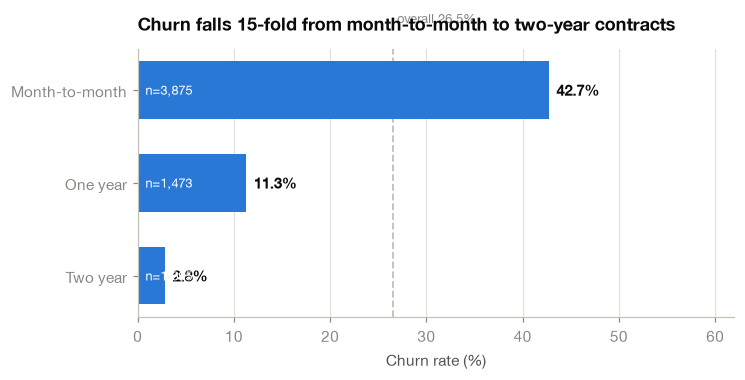

<Axes: title={'left': 'Churn falls 15-fold from month-to-month to two-year contracts'}, xlabel='Churn rate (%)'>

In [4]:
rate_barh("Contract", order=["Two year", "One year", "Month-to-month"],
          title="Churn falls 15-fold from month-to-month to two-year contracts",
          save="02_churn_by_contract.png")

**Finding:** month-to-month customers churn at **42.7%**, one-year at **11.3%**, two-year at
**2.8%** — a 15× gradient, the strongest single association in the dataset. Only 48 of 1,695
two-year customers churned.

**Confound flag:** contract is entangled with tenure (median tenure: month-to-month 12 months,
two-year 64). Long contracts may retain customers, *or* loyal customers may choose long
contracts — the data cannot separate these, and our recommendations will respect that.

## Q3. How does churn relate to tenure?

*Why ask:* if churn concentrates early in the customer lifecycle, retention effort should too.

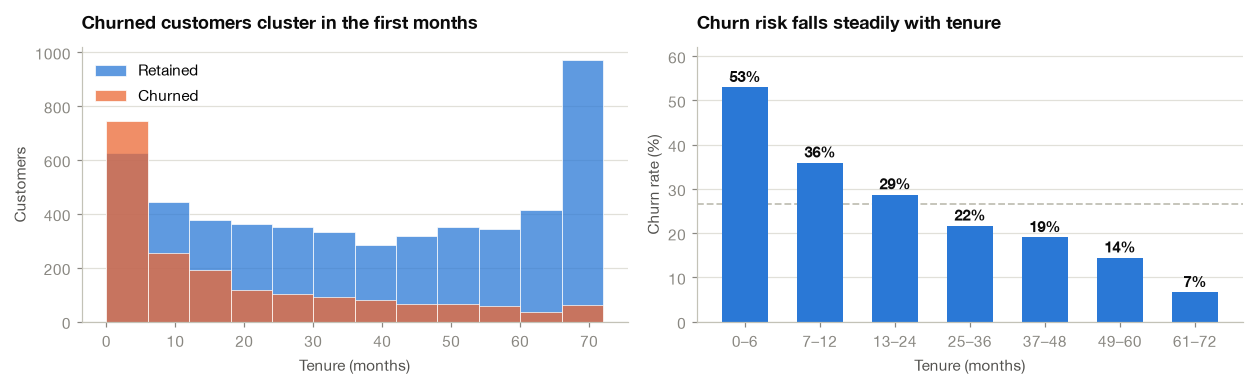

Churn
No     38.0
Yes    10.0


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.6))

bins = np.arange(0, 78, 6)
for label, color, name in [("No", BLUE, "Retained"), ("Yes", ORANGE, "Churned")]:
    axes[0].hist(df.loc[df["Churn"] == label, "tenure"], bins=bins,
                 color=color, alpha=0.75, label=name, edgecolor="white", linewidth=0.6)
axes[0].set_title("Churned customers cluster in the first months", loc="left", pad=12)
axes[0].set_xlabel("Tenure (months)"); axes[0].set_ylabel("Customers")
axes[0].legend(frameon=False)
axes[0].grid(axis="x", visible=False)

buckets = pd.cut(df["tenure"], [-1, 6, 12, 24, 36, 48, 60, 72],
                 labels=["0–6", "7–12", "13–24", "25–36", "37–48", "49–60", "61–72"])
g = df.groupby(buckets, observed=True)["churn01"].agg(rate="mean", n="count")
axes[1].bar(g.index.astype(str), g["rate"] * 100, color=BLUE, width=0.62)
axes[1].axhline(OVERALL * 100, color=BASELINE, lw=1.2, ls="--", zorder=0)
for i, r in enumerate(g["rate"] * 100):
    axes[1].text(i, r + 1.2, f"{r:.0f}%", ha="center", color=INK, fontsize=9.5, fontweight="bold")
axes[1].set_title("Churn risk falls steadily with tenure", loc="left", pad=12)
axes[1].set_xlabel("Tenure (months)"); axes[1].set_ylabel("Churn rate (%)")
axes[1].set_ylim(0, 62); axes[1].grid(axis="x", visible=False)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "03_churn_by_tenure.png", dpi=150, bbox_inches="tight")
plt.show()

print(df.groupby("Churn")["tenure"].median().rename("median tenure (months)").to_string())

**Finding:** churn is front-loaded. Customers in their first 6 months churn at **53%**, falling
monotonically to **7%** for 61–72 months. Median tenure: churners 10 months vs 38 for retained.
The tenure histogram is U-shaped (many new customers, many six-year veterans), and the churned
distribution is squeezed into the left edge.

**Business read (association, not cause):** the first year — especially the first six months —
is where retention capacity matters most. **Modeling read:** tenure will be a top predictor;
its correlation with contract type means tree models may split on either.

## Q4. Do churners pay more per month?

*Why ask:* if price is associated with leaving, pricing and plan design are retention levers.

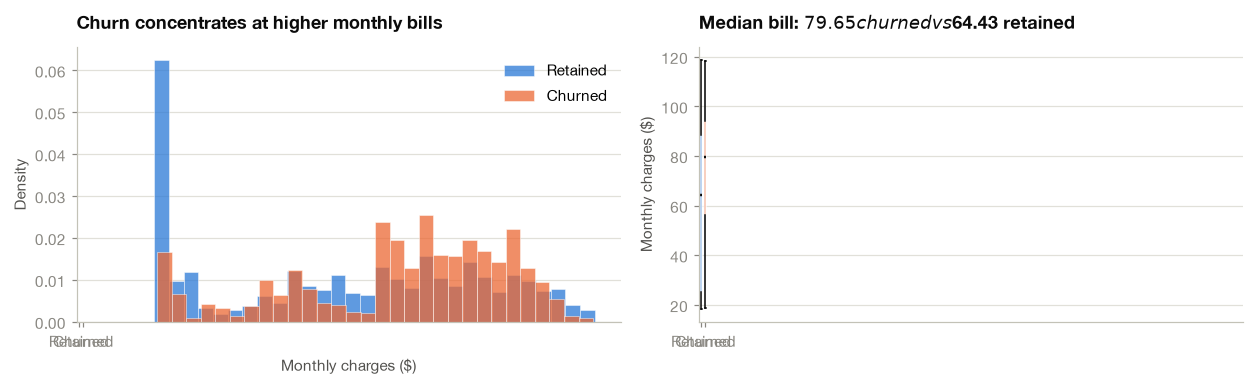

        count   mean    std    min    25%    50%   75%     max
Churn                                                         
No     5174.0  61.27  31.09  18.25  25.10  64.43  88.4  118.75
Yes    1869.0  74.44  24.67  18.85  56.15  79.65  94.2  118.35


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.6), sharex=True)

for label, color, name in [("No", BLUE, "Retained"), ("Yes", ORANGE, "Churned")]:
    axes[0].hist(df.loc[df["Churn"] == label, "MonthlyCharges"], bins=30,
                 color=color, alpha=0.75, label=name, density=True,
                 edgecolor="white", linewidth=0.4)
axes[0].set_title("Churn concentrates at higher monthly bills", loc="left", pad=12)
axes[0].set_xlabel("Monthly charges ($)"); axes[0].set_ylabel("Density")
axes[0].legend(frameon=False); axes[0].grid(axis="x", visible=False)

bp = axes[1].boxplot([df.loc[df["Churn"] == "No", "MonthlyCharges"],
                      df.loc[df["Churn"] == "Yes", "MonthlyCharges"]],
                     tick_labels=["Retained", "Churned"], widths=0.45, patch_artist=True,
                     medianprops=dict(color=INK, lw=1.6))
for patch, color in zip(bp["boxes"], [BLUE, ORANGE]):
    patch.set_facecolor(color); patch.set_alpha(0.8); patch.set_edgecolor("white")
axes[1].set_title("Median bill: $79.65 churned vs $64.43 retained", loc="left", pad=12)
axes[1].set_ylabel("Monthly charges ($)"); axes[1].grid(axis="x", visible=False)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "04_churn_by_monthly_charges.png", dpi=150, bbox_inches="tight")
plt.show()

print(df.groupby("Churn")["MonthlyCharges"].describe().round(2).to_string())

**Finding:** yes — churners' median monthly bill is **\$79.65 vs \$64.43** for retained
customers, and the churned distribution piles up in the \$70–100 band. The retained distribution
is bimodal: a large cheap-plan group (~\$20, mostly no-internet customers, who almost never
churn) and a broad higher band. So "high bill ⇒ churn" is partly a *service-mix* story —
the next question separates it.

## Q5. Is churn associated with internet service type?

*Why ask:* internet service defines the product tier — and fiber is both the premium product
and (as we saw) the expensive one.

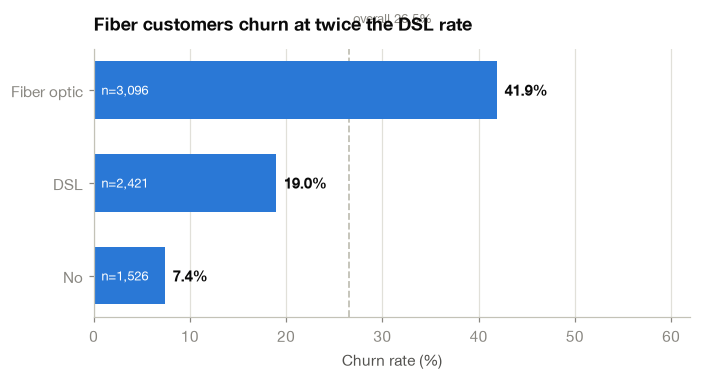

InternetService
DSL            56.15
Fiber optic    91.68
No             20.15


In [7]:
rate_barh("InternetService", order=["No", "DSL", "Fiber optic"],
          title="Fiber customers churn at twice the DSL rate",
          save="05_churn_by_internet.png")
print(df.groupby("InternetService")["MonthlyCharges"].median()
        .rename("median monthly charges ($)").round(2).to_string())

**Finding:** fiber-optic customers churn at **41.9%** — more than double DSL (**19.0%**) and
nearly six times the no-internet group (**7.4%**). Fiber is also the expensive tier (median
\$91.68/month vs \$56.15 DSL vs \$20.15 none), so price and product are confounded here.
Whatever the mechanism — price, service quality, or the kind of customer who buys fiber —
**the fiber base is where the churn mass lives**, and the modeling phases will quantify how much
signal it carries after controlling for other features.

## Q6. Does payment method matter?

*Why ask:* payment friction and billing experience are cheap things to change.

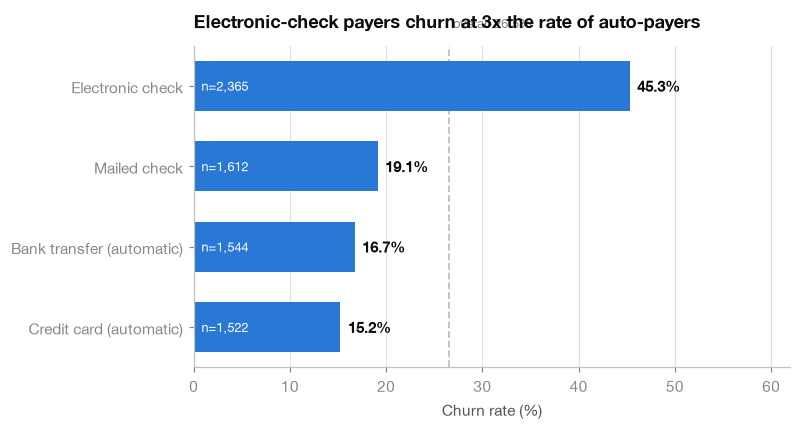

Electronic check: 33.6% of customers, 57.3% of all churners


In [8]:
rate_barh("PaymentMethod",
          order=["Credit card (automatic)", "Bank transfer (automatic)", "Mailed check", "Electronic check"],
          title="Electronic-check payers churn at 3x the rate of auto-payers",
          save="06_churn_by_payment.png")
ec = df["PaymentMethod"] == "Electronic check"
print(f"Electronic check: {ec.mean():.1%} of customers, "
      f"{(ec & (df.churn01 == 1)).sum() / df.churn01.sum():.1%} of all churners")

**Finding:** electronic-check payers churn at **45.3%**, versus 15–17% for automatic payment
methods and 19.1% for mailed checks. This group is a third of the customer base but **57.3% of all
churners**. Both automatic methods look alike (15.2% / 16.7%) — the divide is *manual vs
automatic*, a pattern we'll encode as a feature. (Association, not cause: e-check may proxy for
customers who avoid commitment — note the echo of the contract finding.)

## Q7. Are support and protection services associated with retention? And streaming?

*Why ask:* add-ons are directly marketable. If support services associate with retention and
streaming doesn't, that focuses the offer.

*Method note:* we restrict to internet customers (n=5,517), otherwise the structural
"No internet service" level (7.4% churn) would contaminate the comparison.

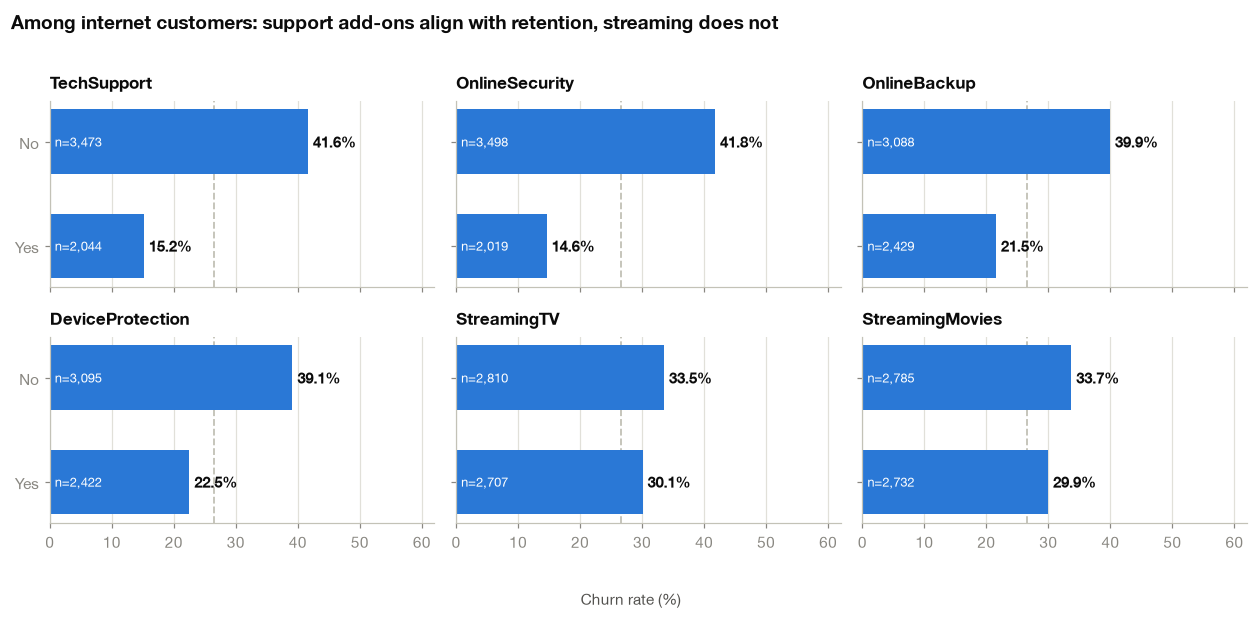

In [9]:
internet = df[df["InternetService"] != "No"]
addon_cols = ["TechSupport", "OnlineSecurity", "OnlineBackup",
              "DeviceProtection", "StreamingTV", "StreamingMovies"]
fig, axes = plt.subplots(2, 3, figsize=(11.5, 5.6), sharey=True, sharex=True)
for ax, col in zip(axes.flat, addon_cols):
    rate_barh(col, order=["Yes", "No"], data=internet, ax=ax)
    ax.set_title(col, loc="left", pad=8, fontsize=11)
    ax.set_xlabel("")
fig.suptitle("Among internet customers: support add-ons align with retention, streaming does not",
             x=0.01, ha="left", fontsize=12.5, fontweight="bold", color=INK)
fig.supxlabel("Churn rate (%)", color=INK2, fontsize=10)
fig.tight_layout(rect=[0, 0.02, 1, 0.97])
fig.savefig(FIGURES_DIR / "07_addon_services.png", dpi=150, bbox_inches="tight")
plt.show()

**Finding:** among internet customers, those *without* TechSupport churn at **41.6% vs 15.2%**
with it; OnlineSecurity shows the same split (**41.8% vs 14.6%**). Backup and device protection
show milder gaps (~40% vs ~22%). Streaming TV/Movies show essentially **no protective
association** (33.5% vs 30.1%) — entertainment add-ons raise the bill without any retention
signature. Support-type services may mark engaged customers rather than protect them — a
selection effect we cannot rule out — but the *pattern* (support ≠ streaming) is a genuine,
actionable asymmetry.

## Q8. Which demographics are associated with churn?

*Why ask:* to know who the at-risk customer *is* — and to check whether any attribute is
irrelevant (also a finding).

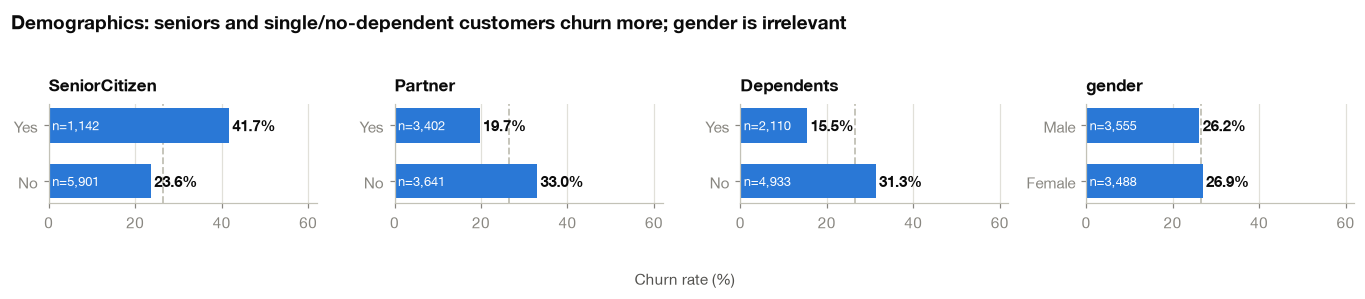

In [10]:
demo_cols = ["SeniorCitizen", "Partner", "Dependents", "gender"]
fig, axes = plt.subplots(1, 4, figsize=(12.5, 2.6), sharex=True)
for ax, col in zip(axes.flat, demo_cols):
    rate_barh(col, order=sorted(df[col].unique()), ax=ax)
    ax.set_title(col, loc="left", pad=8, fontsize=11)
    ax.set_xlabel("")
fig.supxlabel("Churn rate (%)", color=INK2, fontsize=10)
fig.suptitle("Demographics: seniors and single/no-dependent customers churn more; gender is irrelevant",
             x=0.01, ha="left", fontsize=12.5, fontweight="bold", color=INK)
fig.tight_layout(rect=[0, 0.03, 1, 0.95])
fig.savefig(FIGURES_DIR / "08_demographics.png", dpi=150, bbox_inches="tight")
plt.show()

**Finding:** seniors churn at **41.7% vs 23.6%**; customers without partners (**33.0% vs
19.7%**) and without dependents (**31.3% vs 15.5%**) churn more. **Gender shows no association**
(26.9% vs 26.2%) — a useful negative result: we expect it to rank at the bottom of every feature
importance later, and if it doesn't, that's a red flag to investigate. (Phone service and multiple
lines are similarly flat: 26.7% vs 24.9%.)

## Q9. How do the numeric variables relate to each other and to churn?

*Why ask:* to confirm the collinearity found in notebook 01 and see each numeric's direction
of association.

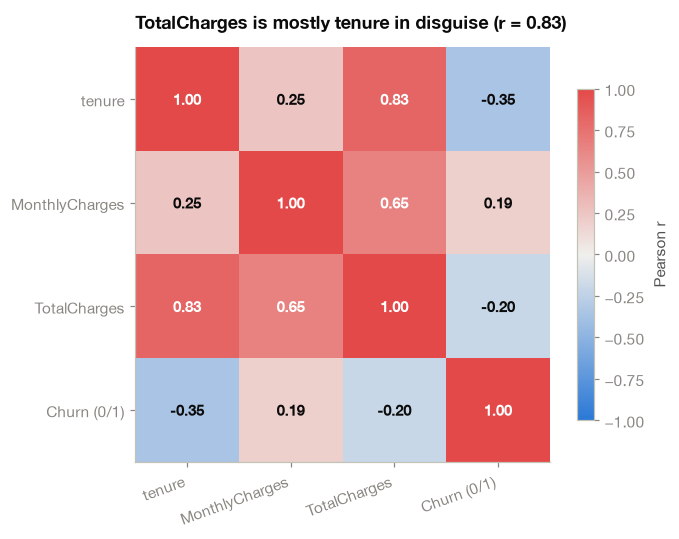

In [11]:
num = df[["tenure", "MonthlyCharges", "TotalCharges", "churn01"]].rename(columns={"churn01": "Churn (0/1)"})
corr = num.corr()

div = LinearSegmentedColormap.from_list("div", [BLUE, "#f0efec", "#e34948"])
fig, ax = plt.subplots(figsize=(6.4, 5))
im = ax.imshow(corr, cmap=div, vmin=-1, vmax=1)
ax.set_xticks(range(4), corr.columns, rotation=20, ha="right")
ax.set_yticks(range(4), corr.columns)
for i in range(4):
    for j in range(4):
        v = corr.iloc[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                color="white" if abs(v) > 0.55 else INK, fontweight="bold")
ax.set_title("TotalCharges is mostly tenure in disguise (r = 0.83)", loc="left", pad=12)
ax.grid(visible=False)
fig.colorbar(im, ax=ax, shrink=0.8, label="Pearson r")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "09_correlations.png", dpi=150, bbox_inches="tight")
plt.show()

**Finding:** `TotalCharges` correlates 0.83 with tenure and 0.65 with monthly charges —
confirming it is nearly a *product* of the other two. Against churn: tenure **−0.35**, monthly
charges **+0.19**, total charges **−0.20**. The apparent paradox — churners pay *more* per month
but have *lower* totals — is fully explained by their short tenure. This is exactly why
`TotalCharges` coefficients would be treacherous to interpret in a linear model, and why
feature engineering (notebook 05) derives a cleaner revenue-rate feature instead.
(Pearson r on a 0/1 target is the point-biserial correlation — fine as a directional summary;
formal tests come in notebook 04.)

## Q10. Where does risk concentrate when factors combine?

*Why ask:* interventions target segments, not single variables. Contract × internet service is
the highest-leverage combination of the two strongest categoricals.

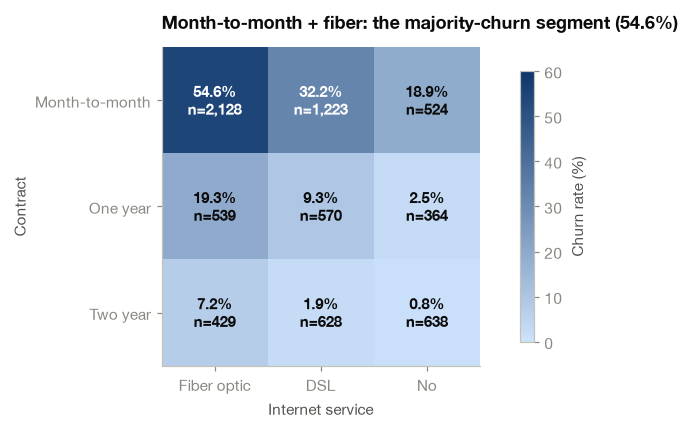

Month-to-month + fiber:                  n=2,128, churn 54.6%
Month-to-month + fiber + no TechSupport: n=1,796, churn 57.5%


In [12]:
pv = df.pivot_table(index="Contract", columns="InternetService", values="churn01", aggfunc="mean") * 100
pv = pv.reindex(index=["Month-to-month", "One year", "Two year"], columns=["Fiber optic", "DSL", "No"])
n = df.pivot_table(index="Contract", columns="InternetService", values="churn01", aggfunc="count") \
      .reindex(index=pv.index, columns=pv.columns)

seq = LinearSegmentedColormap.from_list("seq", ["#cde2fb", "#0d366b"])
fig, ax = plt.subplots(figsize=(7.6, 4))
im = ax.imshow(pv, cmap=seq, vmin=0, vmax=60)
ax.set_xticks(range(3), pv.columns); ax.set_yticks(range(3), pv.index)
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{pv.iloc[i, j]:.1f}%\nn={n.iloc[i, j]:,}", ha="center", va="center",
                color="white" if pv.iloc[i, j] > 30 else INK, fontsize=9.5, fontweight="bold")
ax.set_title("Month-to-month + fiber: the majority-churn segment (54.6%)", loc="left", pad=12)
ax.set_xlabel("Internet service"); ax.set_ylabel("Contract"); ax.grid(visible=False)
fig.colorbar(im, ax=ax, shrink=0.85, label="Churn rate (%)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "10_contract_x_internet.png", dpi=150, bbox_inches="tight")
plt.show()

seg = df[(df["Contract"] == "Month-to-month") & (df["InternetService"] == "Fiber optic")]
seg_ts = seg[seg["TechSupport"] == "No"]
print(f"Month-to-month + fiber:                  n={len(seg):,}, churn {seg.churn01.mean():.1%}")
print(f"Month-to-month + fiber + no TechSupport: n={len(seg_ts):,}, churn {seg_ts.churn01.mean():.1%}")

**Finding:** risk multiplies. Month-to-month fiber customers churn at **54.6%** (n=2,128 —
this single cell holds 30% of the customer base's churn mass); adding "no tech support" sharpens
it to **57.5%** (n=1,796). At the other extreme, two-year no-internet customers churn at **0.8%**.
The spread from best to worst cell is nearly 70:1. This table is the seed of the risk-segmentation
and recommendation phases.

## EDA summary — what we now know

**Ranked associations** (each vs the 26.5% baseline):

| Factor | Churn rate spread | Strength |
|---|---|---|
| Contract | 42.7% (M2M) → 2.8% (2yr) | ★★★ strongest |
| Tenure | 53% (0–6 mo) → 7% (61–72 mo) | ★★★ |
| Payment method | 45.3% (e-check) → 15.2% (auto CC) | ★★★ |
| Internet service | 41.9% (fiber) → 7.4% (none) | ★★★ |
| TechSupport / OnlineSecurity | ~42% (No) → ~15% (Yes)* | ★★ |
| Monthly charges | median $79.65 vs $64.43 | ★★ |
| Senior / Partner / Dependents | 8–18 pt gaps | ★★ |
| Paperless billing | 33.6% vs 16.3% | ★ |
| Streaming add-ons | ~3 pt gap | ~none |
| Gender, phone service | <1–2 pt gap | none |

\* among internet customers.

**The churn-prone profile** (composite of associations, not a causal claim): a newer,
month-to-month customer on fiber internet with a high monthly bill, paying by electronic check,
without support/security add-ons — more often senior, single, and without dependents.

**Carried into later phases:**
- Confounds to remember: contract↔tenure, fiber↔price. EDA can't separate them; we will not
  claim the model does either.
- `TotalCharges` ≈ tenure × monthly charges → engineered rate feature instead (notebook 05).
- Manual-vs-automatic payment is a natural engineered feature.
- Gender/phone service should rank last in importances — a built-in sanity check for the models.
- Hypotheses for formal testing in notebook 04: contract (χ²), internet service (χ²),
  monthly charges (two-sample), tenure (two-sample).
